# Classification with K-nearest neighbors

Now, instead of using a simple logistic regression classifier, we will use a k-nearest neighbors classifier on the GAP-20 dataset.
In particular, we will evaluate whether we can obtain the right class of the polymorph according to the representation

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install dscribe
    !pip install umap-learn
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/05-BasicLearning"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# ase is the package we use to read files related to atomistic structures
from ase import Atoms
from ase.io import read

# we will import the dimensionality reduction and clustering algorithms as well
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics

# dscribe is one package that is widely used for featurization of atomistic structures
from dscribe.descriptors import SOAP

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Loading and featurizing the dataset

The process is identical to the one last time:

In [3]:
dset = read(f"{ROOT}/data/GAP20-reduced.xyz", index=":")

n_structs = len(dset)
n_atoms = sum([len(struct) for struct in dset])

print(n_structs, n_atoms)

140 12030


In [4]:
# retrieve info
LABELS = [
    [struct.info["Polymorph"]] * len(struct)
    for struct in dset
]

# unpack labels
LABELS = np.array([j for i in LABELS for j in i])

print(LABELS)

['Graphite' 'Graphite' 'Graphite' ... 'Liquid' 'Liquid' 'Liquid']


In [5]:
species = ["C"]
r_cut = 5.0
n_max = 6
l_max = 5

soap = SOAP(
    species=species,
    periodic=True,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
)

In [6]:
# creating the representation matrix by concatenating all structures
X = np.concatenate([
    soap.create(struct) for struct in dset
])
X_norm = (X - X.mean(0)) / X.std(0)

# creating the labels based on the names of each structure.
# the labels are defined in a per-atom basis.
enc = OrdinalEncoder()
y = enc.fit_transform(LABELS.reshape(-1, 1)).reshape(-1)

## "Training" a classifier

The process of creating a KNN classifier does not require a model per se. It is simply a process of finding nearest neighbors in the data.
Let's formalize that in code:

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.20)

print(X_train.shape, X_test.shape)

(9624, 126) (2406, 126)


In [8]:
model = KNeighborsClassifier(n_neighbors=5, n_jobs=4)
model.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=4)

Let's make predictions and see how the model performs:

In [9]:
u_train = model.predict(X_train)
u_test = model.predict(X_test)
print(metrics.classification_report(y_test, u_test))

              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       187
         1.0       1.00      1.00      1.00        34
         2.0       1.00      1.00      1.00       187
         3.0       1.00      1.00      1.00       817
         4.0       1.00      1.00      1.00       291
         5.0       0.98      1.00      0.99       844
         6.0       0.96      1.00      0.98        46

    accuracy                           0.99      2406
   macro avg       0.99      0.99      0.99      2406
weighted avg       0.99      0.99      0.99      2406



These results show that the model is indeed performing exceptionally well in classification.
The most interesting results are, in fact, the ones where there is misclassification:

In [10]:
misclassified = y_test != u_test

actual_labels = enc.inverse_transform(y_test[misclassified].reshape(-1, 1))
predicted_labels = enc.inverse_transform(u_test[misclassified].reshape(-1, 1))

for actual, predicted in zip(actual_labels, predicted_labels):
    print(f"ACTUAL = {actual}, PREDICTED = {predicted}")

ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Graphite'], PREDICTED = ['Amorphous_Bulk']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Nanotubes']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Liquid'], PREDICTED = ['Amorphous_Bulk']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Nanotubes']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Amorphous_Bulk'], PREDICTED = ['Liquid']
ACTUAL = ['Liquid'], PREDICTED = ['Amorphous_Bulk']


## Cross-validation

What if the good results above are just a fluke? How do you make sure your model is actually learning something?
One option is to perform a k-fold cross-validation, that splits the data and fits the model to all but one of the splits:

In [11]:
from sklearn.model_selection import cross_val_score, KFold


cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5, n_jobs=4), X_norm, y, cv=cv, scoring="accuracy"
)

In [12]:
print("\nCross-validation scores for each fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.3f}")
print(f"\nMean CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")


Cross-validation scores for each fold:
Fold 1: 0.998
Fold 2: 0.992
Fold 3: 0.994
Fold 4: 0.993
Fold 5: 0.995

Mean CV accuracy: 0.994 (+/- 0.004)


The results above show that this ability to perform classification is **not** an accident: the models and data work well, in such a way that it is possible to predict the polymorph just by looking at the representation.

A good part about the CV is that it gives you security about the data, about the models, and some error bars to predict some variability.

## Hyperparameter optimization

Part of the work we do requires analyzing hyperparameters.
For example, how many neighbors are necessary to make a good prediction?
We can answer these questions by performing hyperparameter optimization and using the k-fold cross validation to make sure our performance is good, but not exactly on the training set.

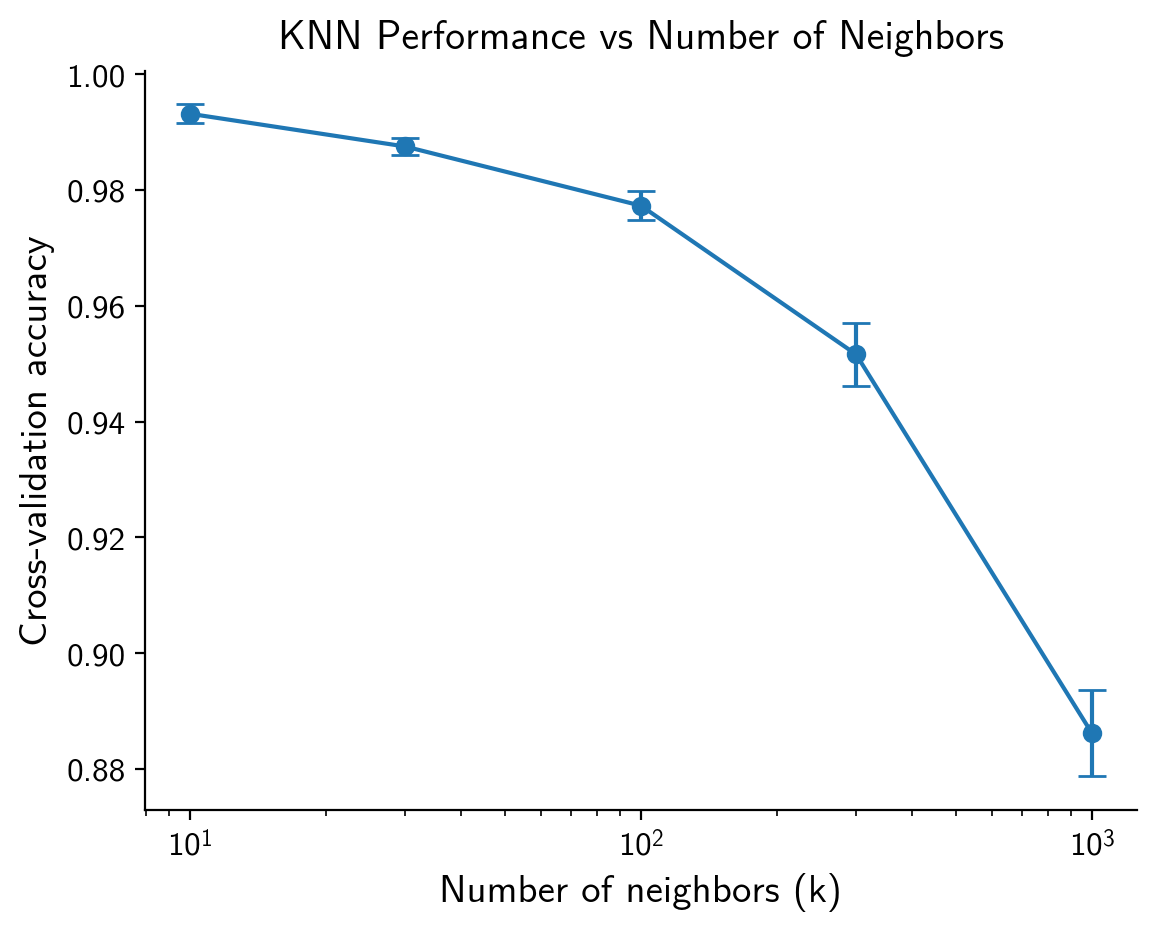

In [13]:
# Let's also try different numbers of neighbors to find the optimal value
n_neighbors_range = [10, 30, 100, 300, 1000]
cv_means = []
cv_stds = []

for k in n_neighbors_range:
    cv_scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, n_jobs=4),
        X_norm,
        y,
        cv=cv,
        scoring="accuracy",
    )
    cv_means.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())

# Plot the cross-validation results for different k values
fig, ax = plt.subplots()
ax.errorbar(n_neighbors_range, cv_means, yerr=cv_stds, fmt="o-", capsize=5)

ax.set_xscale("log")

ax.set_xlabel("Number of neighbors (k)")
ax.set_ylabel("Cross-validation accuracy")
ax.set_title("KNN Performance vs Number of Neighbors")

plt.show()